# 01. Exploração do Catálogo

Aquisição preliminar de dados e inspeção da estrutura do catálogo observacional bruto, tipos de variáveis e taxas de valores faltantes.

> **Nota:** A implementação será adicionada progressivamente durante a Fase 1.

In [ ]:
import psrqpy # puxa o atnf
import pandas as pd
from pathlib import Path
import datetime

In [7]:
query = psrqpy.QueryATNF(params= [
    "JNAME",    # Identificação J2000
    "TYPE",     # Tipo (MSP, Normal, etc)
    "ASSOC",    # Associação (Ex: SNR)
    "RAJ",      # Ascensão Reta
    "DECJ",     # Declinação
    "GL",       # Longitude Galáctica
    "GB",       # Latitude Galáctica
    "DIST",     # Distância estimada (kpc)
    "P0",       # Período de rotação (s)
    "P1",       # Derivada do período (s/s)
    "BSURF",    # Campo magnético superficial (G)
    "AGE",      # Idade característica (anos)
    "EDOT",     # Luminosidade de spin-down (erg/s)
    "DM",       # Medida de dispersão (pc/cm³)
    "S1400",    # Densidade de fluxo a 1400 MHz (mJy)
    "PB"        # Período orbital, se for sistema binário (dias)
    ])

df_raw =  query.pandas

print(f"Foram baixados {df_raw.shape[0]} estrelas de neutrons e {df_raw.shape[1]} colunas")

Foram baixados 4303 estrelas de neutrons e 23 colunas


In [8]:
raw_dir = Path("/home/kiwii/Documentos/estrelas de neutrons/neutron-star-observational-database/data/raw/atnf_raw_arquivos")
hoje = datetime.date.today().isoformat()
caminho = raw_dir / f"atnf_catalog_raw_{hoje}.csv"
df_raw.to_csv(caminho, index=False)



print("Arquivo salvo")


Arquivo salvo


In [ ]:
# checando os dados
df_raw.head()

,JNAME,S1400_ERR,P1,EDOT,DM_ERR,TYPE,GL,PB,DM,AGE,...,DECJ,ASSOC,DECJ_ERR,P0,S1400,P1_ERR,P0_ERR,GB,DIST,BSURF
0,J0002+6216,NaN,5.967033e-15,1.534306e+35,0.6,HE,117.326628,NaN,218.6,3.063207e+05,...,+62:16:09.4,GRS,0.1,0.115364,0.022,6.654376e-20,1.330875e-12,-0.073821,6.357,8.395828e+11
1,J0006+1834,NaN,2.097000e-15,2.479440e+32,0.6,NaN,108.172136,NaN,11.4,5.241664e+06,...,+18:34:59,NaN,4.0,0.693748,NaN,1.200000e-17,1.400000e-10,-42.984988,0.860,1.220534e+12
2,J0007+7303,NaN,3.603905e-13,4.514345e+35,NaN,NRAD,119.659601,NaN,NaN,1.388691e+04,...,+73:03:07.4,GRS,0.8,0.315873,NaN,4.988794e-17,2.993276e-10,10.463079,1.400,1.079675e+13
3,J0011+08,NaN,NaN,NaN,NaN,NaN,106.228269,NaN,24.9,NaN,...,+08:10,NaN,8.0,2.552870,NaN,NaN,NaN,-53.407050,5.399,NaN
4,J0012+5431,NaN,1.281342e-16,1.826919e+29,0.7,RRAT,117.230523,NaN,131.3,3.740843e+08,...,+54:31:40,NaN,9.0,3.025301,NaN,NaN,1.830489e-10,-7.911120,5.427,6.300381e+11


In [ ]:
# calculando a porcentagem de dados faltando para checar qualidade dos dados
dados_faltando = df_raw.isnull().mean() * 100

print("Porcentagem de dados faltando por coluna:")
print(dados_faltando.sort_values(ascending=False).round(2)) # organizando do pior pro melhor

Porcentagem de dados faltando por coluna:
PB_ERR       90.61
PB           89.80
TYPE         86.06
ASSOC        84.36
S1400_ERR    55.98
AGE          36.18
BSURF        36.18
EDOT         36.18
P1_ERR       35.05
P1           34.51
S1400        29.82
P0_ERR       24.75
DM_ERR       24.63
RAJ_ERR      22.19
DECJ_ERR     20.80
DM            2.74
GL            1.72
GB            1.72
DIST          1.72
P0            1.51
RAJ           0.00
DECJ          0.00
JNAME         0.00
dtype: float64


## Mapa Galáctico Bruto

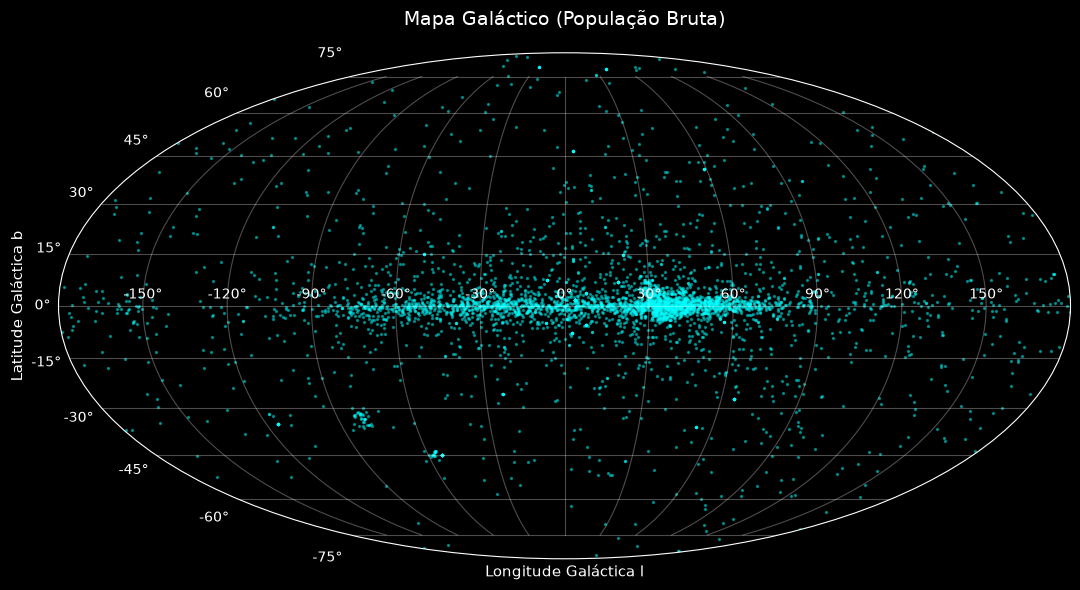

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# removemos linhas que não possuem coordenadas galácticas
df_mapa = df_raw[["GL", "GB"]].dropna()

# a projeção mollweide do matplotlib espera radianos no intervalo [-pi, pi]
l = df_mapa["GL"].copy()
l[l > 180] = l[l > 180] - 360
l_rad = np.deg2rad(l)
b_rad = np.deg2rad(df_mapa["GB"])

fig = plt.figure(figsize=(12, 6), facecolor="black")
ax = fig.add_subplot(111, projection="mollweide")
ax.set_facecolor("black")

# plotando todas as estrelas de nêutrons de forma idêntica (sem cor de categoria)
ax.scatter(l_rad, b_rad, s=2, alpha=0.4, color="cyan")

# configuração visual (grid, bordas e textos em branco para contrastar com fundo preto)
ax.grid(True, color="white", alpha=0.3)
ax.tick_params(colors="white")
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color("white")
for spine in ax.spines.values():
    spine.set_edgecolor("white")

ax.set_title("Mapa Galáctico (População Bruta)", color="white", fontsize=14, pad=20)
ax.set_xlabel("Longitude Galáctica l", fontsize=11, color="white")
ax.set_ylabel("Latitude Galáctica b", fontsize=11, color="white")

plt.tight_layout()
plt.show()
